In [1]:
import tensorflow as tf
tf.keras.backend.clear_session()


2025-08-14 04:31:26.578993: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755145886.781930      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755145886.838881      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import numpy as np
import pandas as pd
import os
import cv2
import math
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import cv2
import os
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
from torchvision.models.vision_transformer import vit_b_16
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


In [3]:
import tensorflow as tf

# Check if GPU is available
if tf.config.list_physical_devices('GPU'):
    print("Using GPU")
else:
    print("Using CPU")

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Using GPU
Num GPUs Available:  2


In [4]:
disease_types = ['Cirrhosis', 'No Fibrosis', 'Periportal Fibrosis','Portal Fibrosis','Septal Fibrosis']
data_dir = '/kaggle/input/resized-dataset256-lung-disease-raw/Resized_Dataset'

In [5]:
train_data = []
for label, disease in enumerate(disease_types):
    for file in os.listdir(os.path.join(data_dir, disease)):
        train_data.append([os.path.join(data_dir, disease, file), label])

df = np.array(train_data)

In [6]:
train_files, val_files = train_test_split(df, test_size=0.3, random_state=42)

In [7]:
# Image Transformations
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])



In [8]:
# Custom Dataset Class
class LungDataset(Dataset):
    def __init__(self, files, transform=None):
        self.files = files
        self.transform = transform
    
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        img_path, label = self.files[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image)
        return image, int(label)

train_dataset = LungDataset(train_files, transform=transform)
val_dataset = LungDataset(val_files, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=5)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = vit_b_16(weights='IMAGENET1K_V1')
model.heads = nn.Linear(model.hidden_dim, len(disease_types))
model.to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:01<00:00, 232MB/s] 


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

def train_model(model, train_loader, val_loader, epochs=20, patience=5):
    best_acc = 0.0
    best_epoch = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    stop_counter = 0 

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            running_loss += loss.item()
        
        val_loss, val_acc = evaluate_model(model, val_loader)
        
        scheduler.step()
        
        # Save history
        history['train_loss'].append(running_loss / len(train_loader))
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {running_loss/len(train_loader):.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Check if validation accuracy improved
        if val_acc > best_acc:
            best_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), "/kaggle/working/best_vit_model.pth")
            stop_counter = 0  
        else:
            stop_counter += 1
        
        # Early stopping condition
        if stop_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}. Validation accuracy did not improve for {patience} epochs.")
            break
    
    return history


In [11]:
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return val_loss / len(dataloader), correct / total

In [12]:
# Train the Model
history = train_model(model, train_loader, val_loader, epochs=20)

# Load Best Model
model.load_state_dict(torch.load("/kaggle/working/best_vit_model.pth"))
model.eval()


100%|██████████| 278/278 [02:43<00:00,  1.71it/s]


Epoch 1/20 - Train Loss: 0.8390, Val Loss: 0.7830, Val Acc: 0.6490, LR: 0.000100


100%|██████████| 278/278 [02:52<00:00,  1.61it/s]


Epoch 2/20 - Train Loss: 0.4995, Val Loss: 0.4458, Val Acc: 0.8077, LR: 0.000100


100%|██████████| 278/278 [02:52<00:00,  1.61it/s]


...

100%|██████████| 278/278 [02:52<00:00,  1.61it/s]


Epoch 16/20 - Train Loss: 0.0001, Val Loss: 0.1212, Val Acc: 0.9774, LR: 0.000010


100%|██████████| 278/278 [02:52<00:00,  1.61it/s]


Epoch 17/20 - Train Loss: 0.0001, Val Loss: 0.1228, Val Acc: 0.9769, LR: 0.000010
Early stopping at epoch 17. Validation accuracy did not improve for 5 epochs.


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

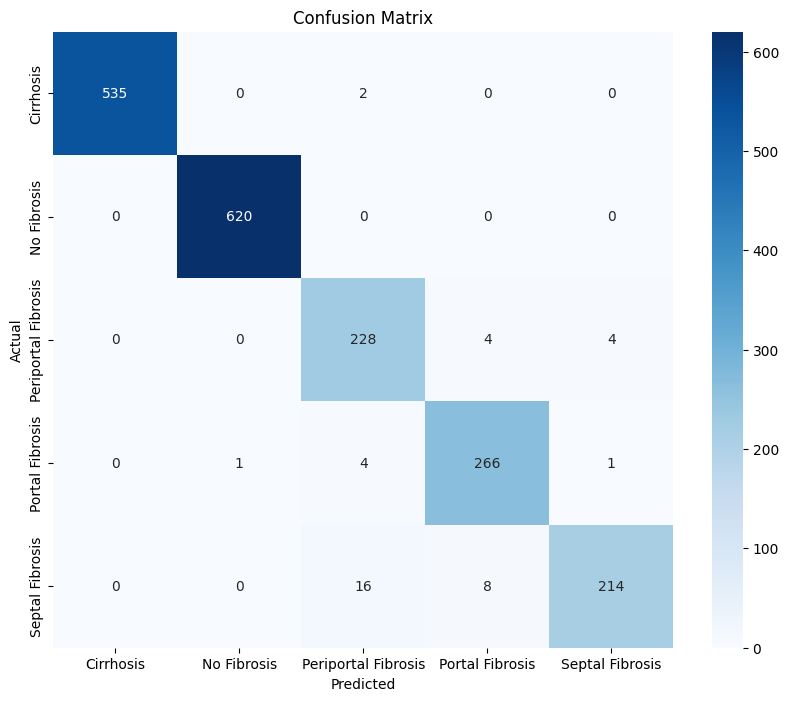

In [13]:
# Evaluate on Validation Set
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=disease_types, yticklabels=disease_types)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred, target_names=disease_types))


                     precision    recall  f1-score   support

          Cirrhosis       1.00      1.00      1.00       537
        No Fibrosis       1.00      1.00      1.00       620
Periportal Fibrosis       0.91      0.97      0.94       236
    Portal Fibrosis       0.96      0.98      0.97       272
    Septal Fibrosis       0.98      0.90      0.94       238

           accuracy                           0.98      1903
          macro avg       0.97      0.97      0.97      1903
       weighted avg       0.98      0.98      0.98      1903



In [15]:
# loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

AttributeError: 'dict' object has no attribute 'history'